In [1]:
import os, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
OUT = "module_3_olist/outputs/"
f = pd.read_parquet("data/processed/olist_funnel.parquet")

DATA_END = pd.Timestamp("2018-08-29")
f["days_observable"] = (DATA_END - f.won_date).dt.days
d = f[f.closed].copy()
d["fair"] = d.days_observable >= 90
print("Closed deals:", len(d), "| with ≥90 days of data:", d.fair.sum())

def scorecard(df, col, min_deals=20):
    s = df.groupby(col).agg(
        deals=("mql_id","count"),
        fair_deals=("fair","sum"),
        fair_activated=("activated", lambda x: x[df.loc[x.index, "fair"]].sum()),
        revenue=("revenue","sum"))
    s["fair_activation_%"] = s.fair_activated / s.fair_deals.where(s.fair_deals > 0) * 100
    s["revenue_per_deal"] = s.revenue / s.deals
    s["revenue_share_%"] = s.revenue / s.revenue.sum() * 100
    return s[s.deals >= min_deals].sort_values("revenue_per_deal", ascending=False).round(1)

Closed deals: 842 | with ≥90 days of data: 663


In [2]:
lt = scorecard(d, "lead_type")
lt.to_csv(OUT + "by_lead_type.csv")
lt

,deals,fair_deals,fair_activated,revenue,fair_activation_%,revenue_per_deal,revenue_share_%
lead_type,,,,,,,
online_big,126,99,71,285084.2,71.7,2262.6,46.0
online_small,77,63,27,52160.4,42.9,677.4,8.4
online_medium,332,268,155,204160.7,57.8,614.9,32.9
online_beginner,57,43,18,22002.6,41.9,386.0,3.6
industry,123,92,35,29078.5,38.0,236.4,4.7
offline,104,82,26,19218.5,31.7,184.8,3.1


In [3]:
bs = scorecard(d, "business_segment", min_deals=15)
bs.to_csv(OUT + "by_business_segment.csv")
bs.sort_values("deals", ascending=False).head(10)

,deals,fair_deals,fair_activated,revenue,fair_activation_%,revenue_per_deal,revenue_share_%
business_segment,,,,,,,
home_decor,105,83,39,43809.3,47.0,417.2,6.6
health_beauty,93,77,41,88924.3,53.2,956.2,13.4
car_accessories,77,63,29,30006.0,46.0,389.7,4.5
household_utilities,71,58,39,51280.9,67.2,722.3,7.7
construction_tools_house_garden,69,54,30,32007.1,55.6,463.9,4.8
audio_video_electronics,64,45,26,49423.4,57.8,772.2,7.4
computers,34,25,10,11772.3,40.0,346.2,1.8
pet,30,26,16,40498.8,61.5,1350.0,6.1
food_supplement,28,21,7,10364.0,33.3,370.1,1.6


In [4]:
bp = scorecard(d.assign(lead_behaviour_profile=d.lead_behaviour_profile.fillna("not recorded")),
               "lead_behaviour_profile", min_deals=10)
bp.to_csv(OUT + "by_behaviour_profile.csv")
bp

,deals,fair_deals,fair_activated,revenue,fair_activation_%,revenue_per_deal,revenue_share_%
lead_behaviour_profile,,,,,,,
shark,24,15,8,46854.3,53.3,1952.3,7.0
not recorded,177,166,88,228319.4,53.0,1289.9,34.3
eagle,123,101,44,88103.9,43.6,716.3,13.3
cat,407,323,168,279586.4,52.0,686.9,42.1
wolf,95,58,32,21278.0,55.2,224.0,3.2


In [5]:
sr = scorecard(d, "sr_id", min_deals=20)
sr.index = [f"SR_{i+1}" for i in range(len(sr))]
sr.to_csv(OUT + "by_sales_rep.csv")
sr

,deals,fair_deals,fair_activated,revenue,fair_activation_%,revenue_per_deal,revenue_share_%
SR_1,51,40,20,135244.6,50.0,2651.9,20.3
SR_2,36,36,15,69115.0,41.7,1919.9,10.4
SR_3,32,32,14,53828.7,43.8,1682.1,8.1
SR_4,24,24,12,18593.7,50.0,774.7,2.8
SR_5,133,116,68,94760.7,58.6,712.5,14.3
SR_6,59,42,16,39925.5,38.1,676.7,6.0
SR_7,24,17,10,15813.6,58.8,658.9,2.4
SR_8,74,67,31,46917.3,46.3,634.0,7.1
SR_9,64,51,27,38984.9,52.9,609.1,5.9
SR_10,82,68,39,45099.0,57.4,550.0,6.8


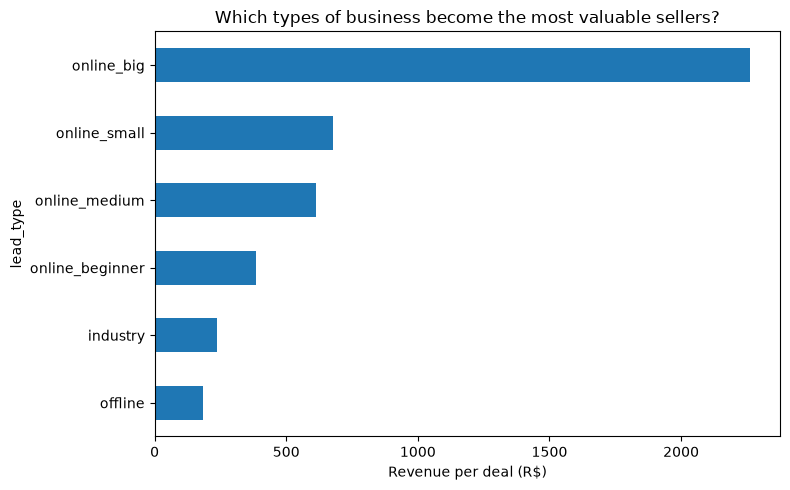

In [6]:
ax = lt.sort_values("revenue_per_deal").revenue_per_deal.plot.barh(figsize=(8,5))
ax.set_xlabel("Revenue per deal (R$)")
ax.set_title("Which types of business become the most valuable sellers?")
plt.tight_layout(); plt.savefig(OUT + "revenue_by_lead_type.png", dpi=150); plt.show()

In [7]:
print(f"""
Best lead type (revenue/deal):  {lt.revenue_per_deal.idxmax()} (R$ {lt.revenue_per_deal.max():,.0f})
Worst lead type (revenue/deal): {lt.revenue_per_deal.idxmin()} (R$ {lt.revenue_per_deal.min():,.0f})
Largest segment by deals:       {bs.deals.idxmax()} ({bs.deals.max()} deals)
Best segment (revenue/deal):    {bs.revenue_per_deal.idxmax()} (R$ {bs.revenue_per_deal.max():,.0f})
Top SR revenue/deal:            R$ {sr.revenue_per_deal.max():,.0f} | Bottom SR: R$ {sr.revenue_per_deal.min():,.0f}
Gap best vs worst SR:           {sr.revenue_per_deal.max()/sr.revenue_per_deal.min():.1f}x
""")


Best lead type (revenue/deal):  online_big (R$ 2,263)
Worst lead type (revenue/deal): offline (R$ 185)
Largest segment by deals:       home_decor (105 deals)
Best segment (revenue/deal):    pet (R$ 1,350)
Top SR revenue/deal:            R$ 2,652 | Bottom SR: R$ 232
Gap best vs worst SR:           11.4x



In [1]:
d["is_online_big"] = d.lead_type == "online_big"
mix = d.groupby("sr_id").agg(deals=("mql_id","count"),
                             big_share=("is_online_big","mean"),
                             revenue_per_deal=("revenue","mean"))
mix = mix[mix.deals >= 20].sort_values("revenue_per_deal", ascending=False)
mix.index = [f"SR_{i+1}" for i in range(len(mix))]
mix["big_share"] = (mix.big_share * 100).round(1)
print("Correlation between 'share of big-shop deals' and revenue per deal:",
      round(mix.big_share.corr(mix.revenue_per_deal), 2))
mix.round(0)

NameError: name 'd' is not defined

In [2]:
import os, pandas as pd
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
f = pd.read_parquet("data/processed/olist_funnel.parquet")
d = f[f.closed].copy()

d["is_online_big"] = d.lead_type == "online_big"
mix = d.groupby("sr_id").agg(deals=("mql_id","count"),
                             big_share=("is_online_big","mean"),
                             revenue_per_deal=("revenue","mean"))
mix = mix[mix.deals >= 20].sort_values("revenue_per_deal", ascending=False)
mix.index = [f"SR_{i+1}" for i in range(len(mix))]
mix["big_share"] = (mix.big_share * 100).round(1)
print("Correlation between 'share of big-shop deals' and revenue per deal:",
      round(mix.big_share.corr(mix.revenue_per_deal), 2))
mix.round(0)

Correlation between 'share of big-shop deals' and revenue per deal: -0.42


,deals,big_share,revenue_per_deal
SR_1,51,12.0,2652.0
SR_2,36,8.0,1920.0
SR_3,32,6.0,1682.0
SR_4,24,17.0,775.0
SR_5,133,16.0,712.0
SR_6,59,15.0,677.0
SR_7,24,8.0,659.0
SR_8,74,14.0,634.0
SR_9,64,20.0,609.0
SR_10,82,21.0,550.0


In [3]:
g = d.groupby("sr_id").revenue
chk = pd.DataFrame({
    "deals": g.size(),
    "mean_rev": g.mean(),
    "median_rev": g.median(),
    "top_seller_share_%": g.max() / g.sum() * 100,
})
chk = chk[chk.deals >= 20].sort_values("mean_rev", ascending=False)
chk.index = [f"SR_{i+1}" for i in range(len(chk))]
chk.round(1).head(5)

,deals,mean_rev,median_rev,top_seller_share_%
SR_1,51,2651.9,0.0,83.1
SR_2,36,1919.9,0.0,64.0
SR_3,32,1682.1,0.0,67.4
SR_4,24,774.7,21.4,38.2
SR_5,133,712.5,125.0,12.7
